In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Hypothesis.
Null Hypothesis: There is no difference in retention rates between the gate_30 group and the gate_40 group. Any observed difference is due to random chance.
Mathematically: $P_{30} = P_{40}$ (where $P$ is the probability of retention).
Alternative Hypothesis ($H_a$): There is a statistically significant difference in retention rates between the gate_30 group and the gate_40 group.
Mathematically: $P_{30} \neq P_{40}$

# Data Wrangling

In [2]:
# --- Step 1: Load and Clean ---
df = pd.read_csv('cookie_cats.csv')
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [3]:
df.columns.isnull() # Check for missing values in columns
# No missing values in columns

array([False, False, False, False, False])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


# Exploratory Data Analysis.(EDA)

<Axes: ylabel='sum_gamerounds'>

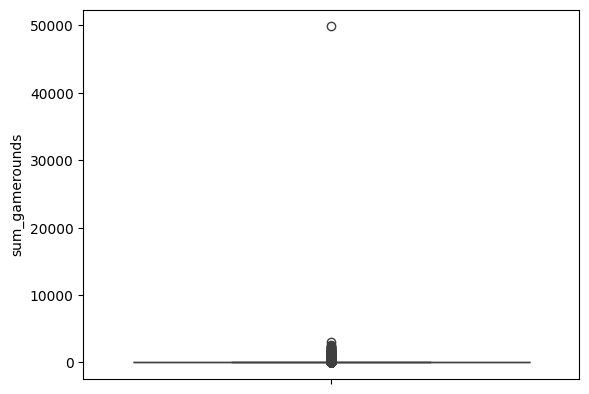

In [5]:
sns.boxplot(y=df['sum_gamerounds'])
# Presence of outliers in sum_gamerounds ie 50000+ gamerounds.

Skewness Coefficient: 185.44


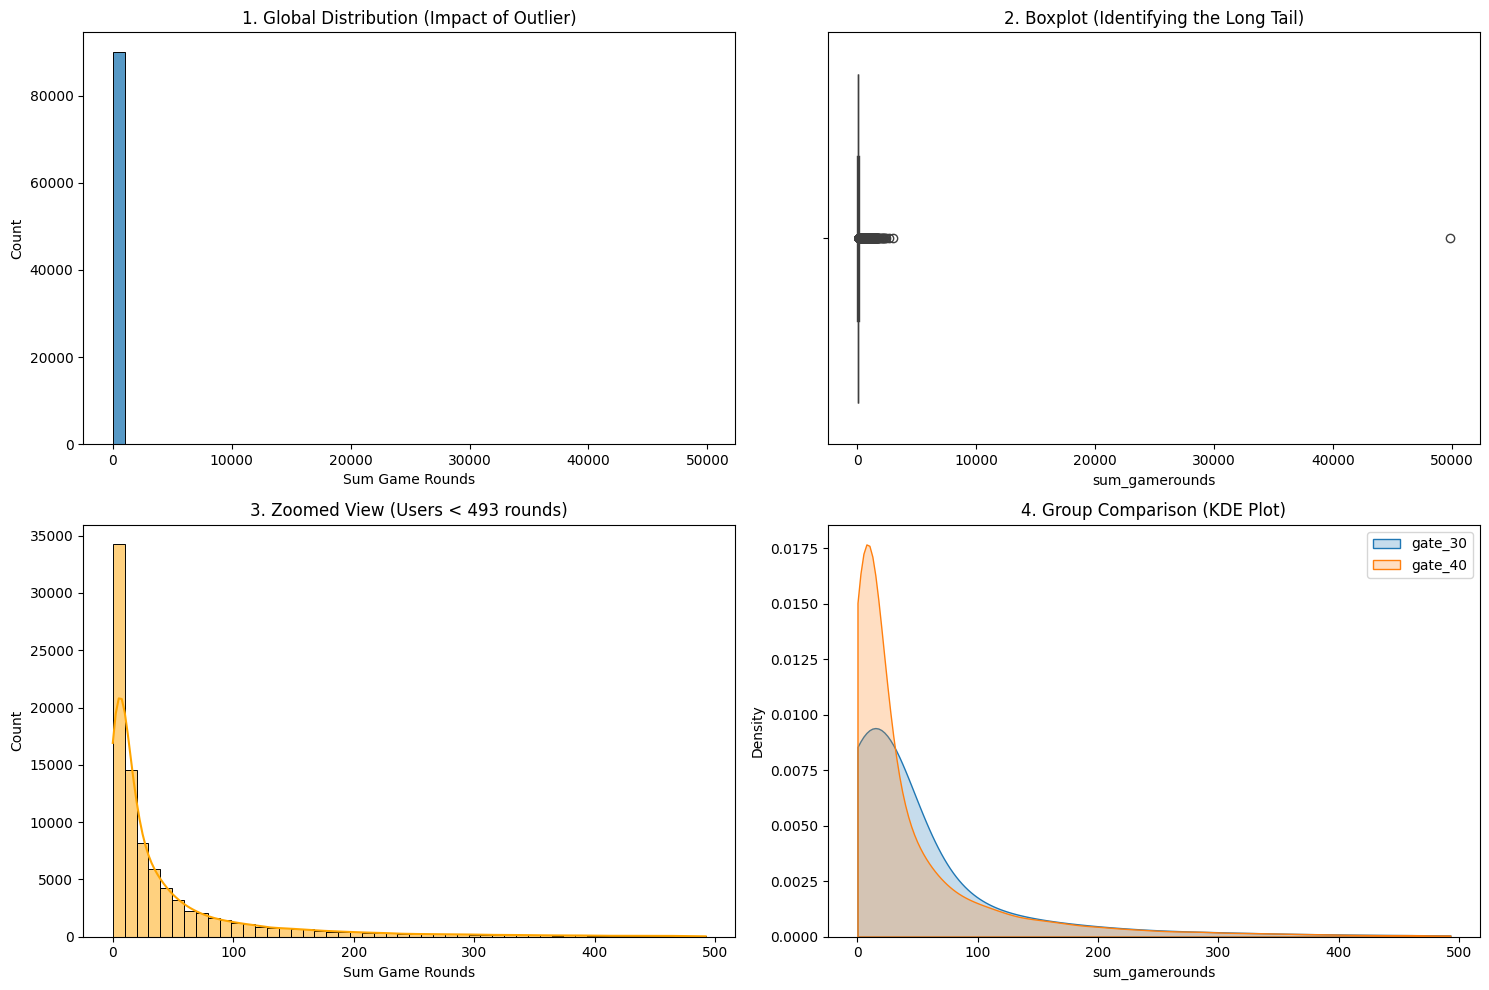

In [9]:
#Skewness of the Data
# Create a multi-panel figure
plt.figure(figsize=(15, 10))

# --- Plot 1: Global Histogram ---
# This shows how one outlier makes the rest of the data invisible
plt.subplot(2, 2, 1)
sns.histplot(df['sum_gamerounds'], bins=50, kde=False)
plt.title('1. Global Distribution (Impact of Outlier)')
plt.xlabel('Sum Game Rounds')

# --- Plot 2: Boxplot ---
# This highlights the "long tail" of the distribution
plt.subplot(2, 2, 2)
sns.boxplot(x=df['sum_gamerounds'])
plt.title('2. Boxplot (Identifying the Long Tail)')

# --- Plot 3: Zoomed Histogram (Bottom 99% of players) ---
# By removing the top 1%, we can finally see the shape of the data
upper_limit = df['sum_gamerounds'].quantile(0.99)
filtered_df = df[df['sum_gamerounds'] < upper_limit]

plt.subplot(2, 2, 3)
sns.histplot(filtered_df['sum_gamerounds'], bins=50, kde=True, color='orange')
plt.title(f'3. Zoomed View (Users < {upper_limit:.0f} rounds)')
plt.xlabel('Sum Game Rounds')

# --- Plot 4: Density Plot Comparison ---
# Comparing the two versions side-by-side
plt.subplot(2, 2, 4)
sns.kdeplot(df[df['version'] == 'gate_30']['sum_gamerounds'], label='gate_30', fill=True, clip=(0, upper_limit))
sns.kdeplot(df[df['version'] == 'gate_40']['sum_gamerounds'], label='gate_40', fill=True, clip=(0, upper_limit))
plt.title('4. Group Comparison (KDE Plot)')
plt.legend()

plt.tight_layout()
plt.savefig('skewness_report.png')

# Calculate the numerical skewness coefficient
print(f"Skewness Coefficient: {df['sum_gamerounds'].skew():.2f}")

In [11]:
# --- Step 2: Statistical Testing (Game Rounds) ---
# We use Mann-Whitney U because the data is highly skewed
group_30 = df[df['version'] == 'gate_30']['sum_gamerounds']
group_40 = df[df['version'] == 'gate_40']['sum_gamerounds']

stat, p_val = mannwhitneyu(group_30, group_40)
print(f"Mann-Whitney U Test p-value: {p_val:.4f}")

Mann-Whitney U Test p-value: 0.0502


In [14]:
# --- Step 3: Bootstrapping (1-Day Retention) ---
# We want to see the certainty of the difference in retention
boot_1d = []
for i in range(1000):
    # Resample the data and calculate the mean for each group
    boot_mean = df.sample(frac=1, replace=True).groupby('version')['retention_1'].mean()
    boot_1d.append(boot_mean)

boot_1d = pd.DataFrame(boot_1d)
boot_1d.head()

version,gate_30,gate_40
retention_1,0.450027,0.442912
retention_1,0.446447,0.443277
retention_1,0.443749,0.443304
retention_1,0.447877,0.440610
retention_1,0.444991,0.439974


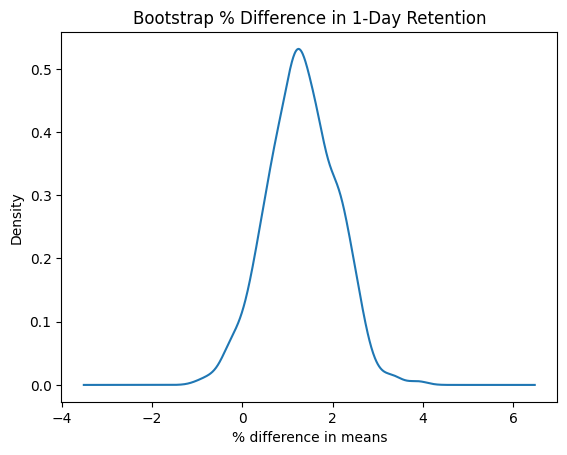

In [15]:
# Calculate the difference between the two groups
boot_1d['diff'] = (boot_1d['gate_30'] - boot_1d['gate_40']) / boot_1d['gate_40'] * 100

# Plot the bootstrap differences
ax = boot_1d['diff'].plot(kind='kde')
ax.set_xlabel("% difference in means")
ax.set_title("Bootstrap % Difference in 1-Day Retention")
plt.show()


In [16]:
# --- Step 4: Conclusion ---
prob = (boot_1d['gate_30'] > boot_1d['gate_40']).mean()
print(f"Probability that 1-day retention is higher when gate is at level 30: {prob:.1%}")


Probability that 1-day retention is higher when gate is at level 30: 95.8%


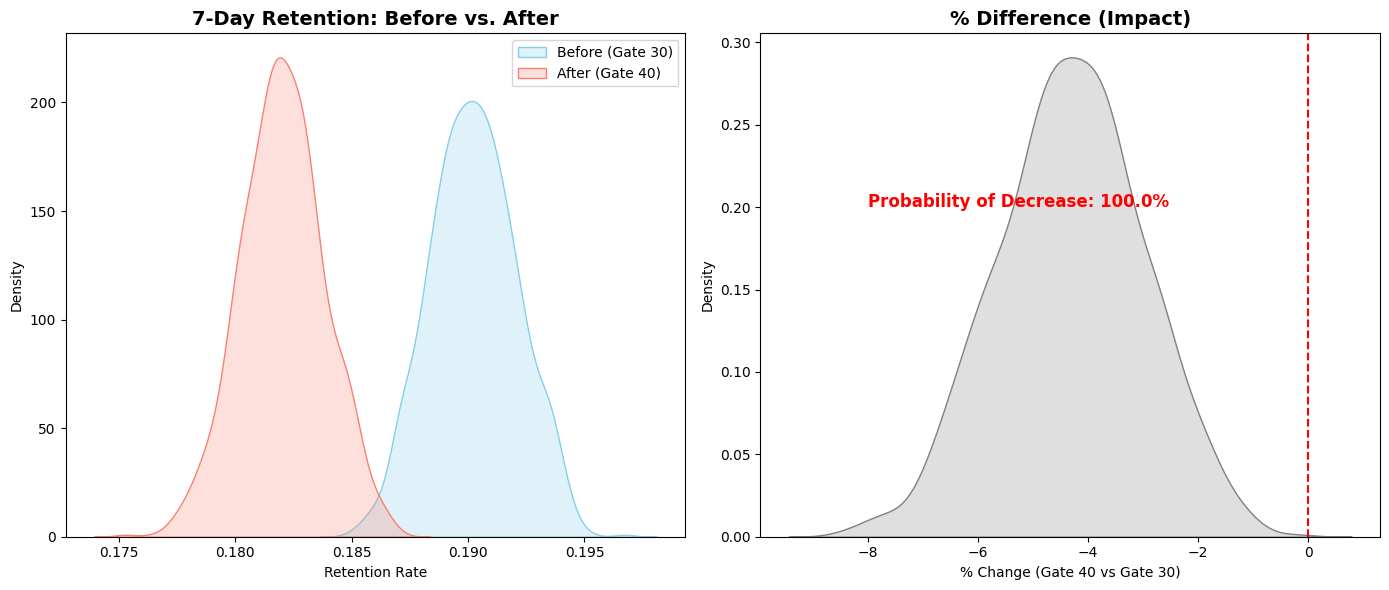

In [ ]:

# --- Step 5: Final Visualization (Before vs After + The Difference) ---

# Bootstrap 7-day retention (the most important metric for games)
boot_7d = []
for i in range(1000):
    boot_mean = df.sample(frac=1, replace=True).groupby('version')['retention_7'].mean()
    boot_7d.append(boot_mean)

boot_7d = pd.DataFrame(boot_7d)
boot_7d['diff'] = (boot_7d['gate_40'] - boot_7d['gate_30']) / boot_7d['gate_30'] * 100

# Final Visualization
plt.figure(figsize=(14, 6))

# Subplot 1: "Before vs After" (Comparison of Distributions)
plt.subplot(1, 2, 1)
sns.kdeplot(boot_7d['gate_30'], label='Before (Gate 30)', fill=True, color='skyblue')
sns.kdeplot(boot_7d['gate_40'], label='After (Gate 40)', fill=True, color='salmon')
plt.title('7-Day Retention: Before vs. After', fontsize=14, fontweight='bold')
plt.xlabel('Retention Rate')
plt.legend()

# Subplot 2: "The Difference" (The Impact of the Change)
plt.subplot(1, 2, 2)
sns.kdeplot(boot_7d['diff'], fill=True, color='grey')
plt.axvline(x=0, color='red', linestyle='--') # The "No Change" line
plt.title('% Difference (Impact)', fontsize=14, fontweight='bold')
plt.xlabel('% Change (Gate 40 vs Gate 30)')

# Calculate probability of decrease
prob_decrease = (boot_7d['diff'] < 0).mean()
plt.text(-8, 0.2, f'Probability of Decrease: {prob_decrease:.1%}',
         color='red', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('final_ab_test_result.png')